# TEAM 7's NoteBook


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [4]:
#LOAD DATA
df = pd.read_csv('data_for_IoT.csv')
X = df[['Temp', 'Humidity', 'LDR']].values
y = df['Heater'].values

DATA VISUALIZATION


Text(0.5, 1.0, 'Light Level Distribution')

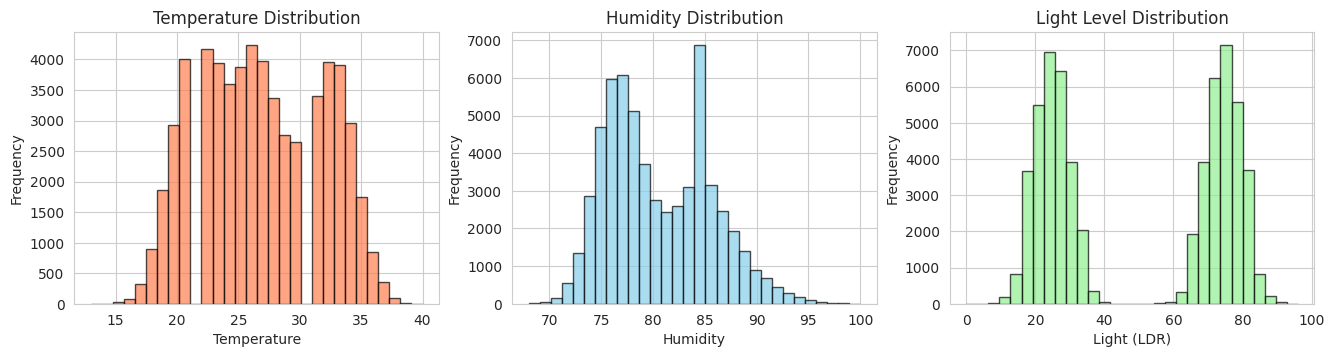

In [5]:
fig = plt.figure(figsize=(16, 12))
# 1. FEATURE DISTRIBUTIONS
ax1 = plt.subplot(3, 3, 1)
df['Temp'].hist(bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')

ax2 = plt.subplot(3, 3, 2)
df['Humidity'].hist(bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.title('Humidity Distribution')

ax3 = plt.subplot(3, 3, 3)
df['LDR'].hist(bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Light (LDR)')
plt.ylabel('Frequency')
plt.title('Light Level Distribution')

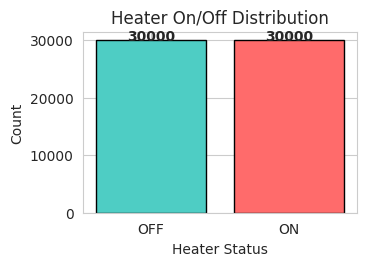

In [6]:
# HEATER STATUS DISTRIBUTION
ax4 = plt.subplot(3, 3, 4)
heater_counts = df['Heater'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(heater_counts.index, heater_counts.values, color=colors, edgecolor='black')
plt.xlabel('Heater Status')
plt.ylabel('Count')
plt.title('Heater On/Off Distribution')
plt.xticks([0, 1], ['OFF', 'ON'])
for i, v in enumerate(heater_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

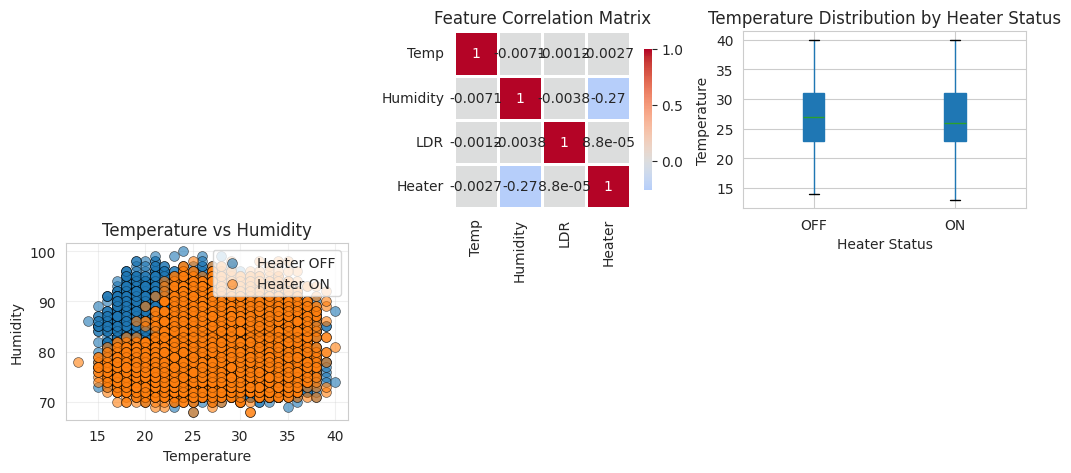

In [7]:
#  CORRELATION HEATMAP
ax5 = plt.subplot(3, 3, 5)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')

#  TEMPERATURE VS HEATER (Box Plot)
ax6 = plt.subplot(3, 3, 6)
df.boxplot(column='Temp', by='Heater', ax=ax6, patch_artist=True)
plt.xlabel('Heater Status')
plt.ylabel('Temperature')
plt.title('Temperature Distribution by Heater Status')
plt.suptitle('')  # Remove default title
ax6.set_xticklabels(['OFF', 'ON'])

# 5.  TEMPERATURE VS HUMIDITY (Colored by Heater)
ax7 = plt.subplot(3, 3, 7)
for heater_val in [0, 1]:
    mask = df['Heater'] == heater_val
    plt.scatter(df[mask]['Temp'], df[mask]['Humidity'],
                label=f'Heater {"ON" if heater_val else "OFF"}',
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature vs Humidity')
plt.legend()
plt.grid(True, alpha=0.3)

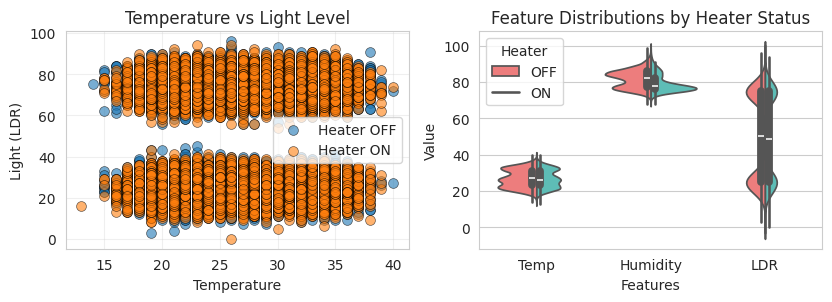

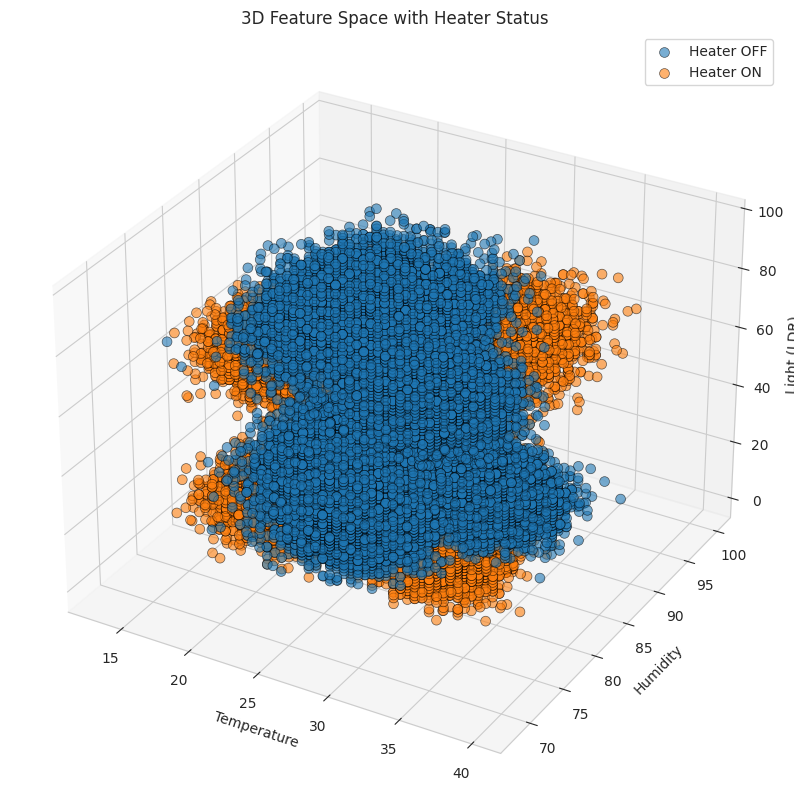

Creating pairplot (this may take a moment)...


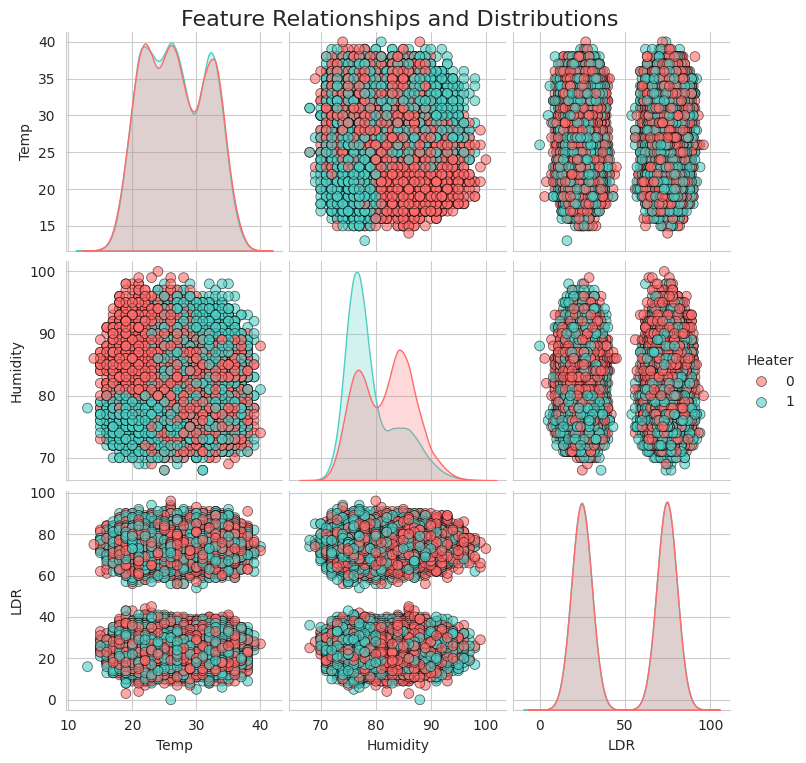


DATASET STATISTICAL SUMMARY
               Temp      Humidity           LDR        Heater
count  60000.000000  60000.000000  60000.000000  60000.000000
mean      26.822483     80.507850     49.553633      0.500000
std        4.919079      5.024984     25.482237      0.500004
min       13.000000     68.000000      0.000000      0.000000
25%       23.000000     76.000000     25.000000      0.000000
50%       27.000000     79.000000     49.500000      0.500000
75%       31.000000     85.000000     75.000000      1.000000
max       40.000000    100.000000     96.000000      1.000000

HEATER STATUS DISTRIBUTION
Heater
1    30000
0    30000
Name: count, dtype: int64

Heater ON: 50.00%
Heater OFF: 50.00%

FEATURE STATISTICS BY HEATER STATUS
Heater                     0             1
Temp     count  30000.000000  30000.000000
         mean      26.835733     26.809233
         std        4.947872      4.890164
         min       14.000000     13.000000
         25%       23.000000     23.0000

In [8]:


# 6. SCATTER: TEMPERATURE VS LDR (Colored by Heater)
ax8 = plt.subplot(3, 3, 8)
for heater_val in [0, 1]:
    mask = df['Heater'] == heater_val
    plt.scatter(df[mask]['Temp'], df[mask]['LDR'],
                label=f'Heater {"ON" if heater_val else "OFF"}',
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Temperature')
plt.ylabel('Light (LDR)')
plt.title('Temperature vs Light Level')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. VIOLIN PLOT: ALL FEATURES BY HEATER STATUS
ax9 = plt.subplot(3, 3, 9)
df_melted = df.melt(id_vars=['Heater'], value_vars=['Temp', 'Humidity', 'LDR'])
sns.violinplot(x='variable', y='value', hue='Heater', data=df_melted,
               split=True, palette={0: '#ff6b6b', 1: '#4ecdc4'}, ax=ax9)
plt.xlabel('Features')
plt.ylabel('Value')
plt.title('Feature Distributions by Heater Status')
plt.legend(title='Heater', labels=['OFF', 'ON'])

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

# ADDITIONAL VISUALIZATIONS
# Create 3D scatter plot
fig2 = plt.figure(figsize=(12, 10))
ax = fig2.add_subplot(111, projection='3d')

for heater_val in [0, 1]:
    mask = df['Heater'] == heater_val
    ax.scatter(df[mask]['Temp'], df[mask]['Humidity'], df[mask]['LDR'],
               label=f'Heater {"ON" if heater_val else "OFF"}',
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Temperature')
ax.set_ylabel('Humidity')
ax.set_zlabel('Light (LDR)')
ax.set_title('3D Feature Space with Heater Status')
ax.legend()
plt.savefig('3d_feature_space.png', dpi=300, bbox_inches='tight')
plt.show()

# PAIRPLOT for comprehensive view
print("Creating pairplot (this may take a moment)...")
pair_plot = sns.pairplot(df, hue='Heater', palette={0: '#ff6b6b', 1: '#4ecdc4'},
                         diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'black'})
pair_plot.fig.suptitle('Feature Relationships and Distributions', y=1.01, fontsize=16)
plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

# STATISTICAL SUMMARY
print("\n" + "="*50)
print("DATASET STATISTICAL SUMMARY")
print("="*50)
print(df.describe())
print("\n" + "="*50)
print("HEATER STATUS DISTRIBUTION")
print("="*50)
print(df['Heater'].value_counts())
print(f"\nHeater ON: {(df['Heater'].sum() / len(df)) * 100:.2f}%")
print(f"Heater OFF: {((len(df) - df['Heater'].sum()) / len(df)) * 100:.2f}%")

# FEATURE STATISTICS BY HEATER STATUS
print("\n" + "="*50)
print("FEATURE STATISTICS BY HEATER STATUS")
print("="*50)
print(df.groupby('Heater').describe().T)

In [9]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean: {scaler.mean_}")
print(f"Scale: {scaler.scale_}")

Mean: [26.82248333 80.50785    49.55363333]
Scale: [ 4.9190383   5.02494163 25.48202484]


# SPLITING DATA

In [10]:

X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [11]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TRAINING

In [13]:

print("\n--- Training Neural Network ---")
model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=1)


--- Training Neural Network ---
Epoch 1/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6638 - loss: 0.5952 - val_accuracy: 0.8450 - val_loss: 0.3945
Epoch 2/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8407 - loss: 0.3880 - val_accuracy: 0.8553 - val_loss: 0.3607
Epoch 3/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8541 - loss: 0.3580 - val_accuracy: 0.8608 - val_loss: 0.3473
Epoch 4/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8527 - loss: 0.3522 - val_accuracy: 0.8589 - val_loss: 0.3436
Epoch 5/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8557 - loss: 0.3423 - val_accuracy: 0.8594 - val_loss: 0.3359
Epoch 6/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8535 - loss: 0.3439 - val_accuracy: 0.8614 - val_loss: 0.3328
Epoch 7/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8568 - loss: 0.3376 - val_accuracy: 0.8596 - val_loss: 0.3322
Epoch 8/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - a

In [14]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8529 - loss: 0.3391

Test Accuracy: 85.47%


In [15]:
model.save('model.keras')
print("Saved Keras model as 'model.keras'")

Saved Keras model as 'model.keras'


In [16]:

print("\n Converting to TFLite ")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Enable Quantization


 Converting to TFLite 


In [17]:

def representative_dataset():
    for i in range(100):
        yield [X_train[i].astype(np.float32).reshape(1, 3)]

converter.representative_dataset = representative_dataset
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp4w8conzj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133888178725200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133888178726160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133888178724816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133888178722320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133888178726736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133888178724432: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [18]:
# Save TFLite file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Saved 'model.tflite'")

Saved 'model.tflite'


In [19]:
# CONVERT TO C HEADER (Hex Dump)
def hex_to_c_array(data, model_name="model"):
    c_str = ""
    c_str += "#include <cstddef>\n"
    c_str += "#include <cstdint>\n\n"
    c_str += f"const unsigned int {model_name}_len = {len(data)};\n"
    c_str += f"const unsigned char {model_name}_data[] = {{\n"

    hex_array = []
    for i, val in enumerate(data):
        hex_array.append(f"0x{val:02x}")
        if (i + 1) % 12 == 0:
            c_str += "  " + ", ".join(hex_array) + ",\n"
            hex_array = []

    if hex_array:
        c_str += "  " + ", ".join(hex_array) + "\n"

    c_str += "};\n"
    return c_str

c_header = hex_to_c_array(tflite_model)
with open('model.h', 'w') as f:
    f.write(c_header)

print("Saved 'model.h' ")

Saved 'model.h' 


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Training Accuracy: 85.68%
Validation Accuracy: 86.28%
Test Accuracy: 85.47%


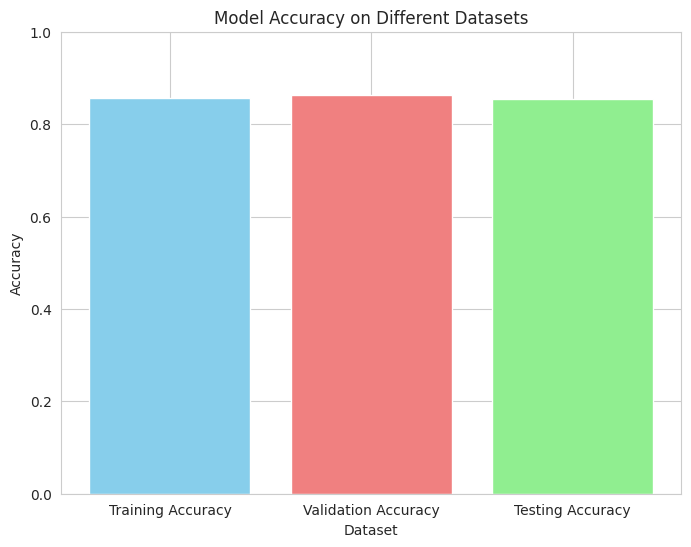

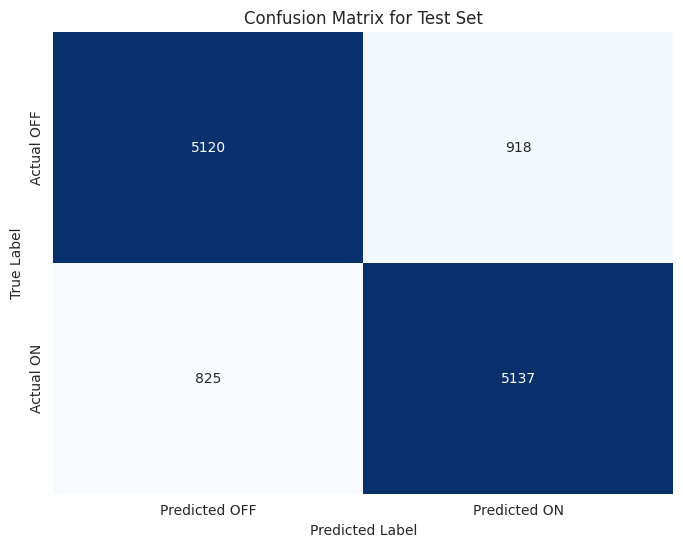

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make predictions for training, validation, and test sets
y_train_pred_proba = model.predict(X_train)
y_val_pred_proba = model.predict(X_val)
y_test_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
y_train_pred = (y_train_pred_proba > 0.5).astype(int)
y_val_pred = (y_val_pred_proba > 0.5).astype(int)
y_test_pred = (y_test_pred_proba > 0.5).astype(int)

# Calculate accuracies
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plot accuracy graph
plt.figure(figsize=(8, 6))
plt.bar(['Training Accuracy', 'Validation Accuracy', 'Testing Accuracy'], [train_acc, val_acc, test_acc], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.title('Model Accuracy on Different Datasets')
plt.ylim(0, 1)
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted OFF', 'Predicted ON'],
            yticklabels=['Actual OFF', 'Actual ON'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()